# Ejercicio 2 — Newton-Krylov matriz-libre sobre la ecuación de Bratu

**Métodos Numéricos II (DAT-252) — UMSA**
Estrategias para la convergencia global · Métodos de Newton-Krylov

Ecuación de Bratu (combustión, teoría de la ignición) en 1D:

$$ u''(x) + \lambda\,e^{u(x)} = 0, \qquad u(0) = u(1) = 0 $$

Con `N = 250` el Jacobiano tendría 62 500 entradas: nadie quiere formarlo, y menos
invertirlo. Este notebook muestra el método completo y responde a la pregunta que
decide el costo: **¿cuán exactamente hay que resolver el sistema lineal de Newton?**

| Parte | Qué muestra |
|---|---|
| A | El Jacobiano nunca se construye: `J·v` sale de una evaluación de `F` |
| B y C | Barrido del término de forzado η — el *oversolving* |
| D | Precondicionamiento: el mismo problema, mucho menos trabajo |
| E | Contraste con `scipy.optimize.newton_krylov` |

In [1]:
import os, time, warnings
import numpy as np
import scipy.sparse as sp
import scipy.sparse.linalg as spla
from scipy.optimize import newton_krylov as scipy_newton_krylov

import nk_lib
from nk_lib import estilo_figuras, tabla, titulo

warnings.filterwarnings("ignore")
plt = estilo_figuras()
%matplotlib inline

SALIDA = "figuras"
os.makedirs(SALIDA, exist_ok=True)

N = 250                 # nodos interiores
LAMBDA = 3.0            # parámetro de Bratu (el punto de retorno está en ≈3.5138)
H = 1.0 / (N + 1)
MALLA = np.linspace(0.0, 1.0, N + 2)[1:-1]

## El problema discreto

In [2]:
def F_bratu(u):
    """Residuo discreto de Bratu, multiplicado por h².

    F_i(u) = −[ (u_{i−1} − 2u_i + u_{i+1})/h² + λ e^{u_i} ] · h²

    Dos decisiones que NO son cosméticas:

    · El signo. Se escribe con un menos delante para que el Jacobiano quede
      DEFINIDO POSITIVO. Newton es invariante ante el signo, pero la
      continuación pseudo-transitoria no lo es: el flujo du/dt = −F(u) debe
      ser estable, y eso exige F' definida positiva.
    · El factor h². Sin él las entradas de J son de orden 1/h² = 1.6·10⁵ y el
      residuo queda mal escalado; con él, todo es de orden 1. Newton tampoco
      lo nota, pero la función de mérito y el radio de la región de confianza
      sí, porque no son invariantes ante reescalados.
    """
    ub = np.zeros(N + 2)
    ub[1:-1] = u
    lap = (ub[:-2] - 2.0 * ub[1:-1] + ub[2:]) / H ** 2
    return -(lap + LAMBDA * np.exp(u)) * H ** 2

In [3]:
def J_bratu_analitico(u):
    """Jacobiano analítico y disperso. Solo se usa para VERIFICAR y para
    construir el precondicionador; el solver nunca lo necesita."""
    principal = 2.0 - H ** 2 * LAMBDA * np.exp(u)
    fuera = -np.ones(N - 1)
    return sp.diags([fuera, principal, fuera], [-1, 0, 1], format="csc")


def precondicionador_laplaciano():
    """M⁻¹ ≈ (parte lineal de J)⁻¹, factorizada UNA sola vez.

    El precondicionador ideal sería J⁻¹, pero eso es el problema que queríamos
    evitar. La idea práctica: quedarse con la parte del operador que es barata
    de invertir —aquí el laplaciano discreto, tridiagonal— y dejar que Krylov
    se encargue del resto. Se factoriza una vez y se reutiliza siempre.
    """
    L = sp.diags([-np.ones(N - 1), 2.0 * np.ones(N), -np.ones(N - 1)],
                 [-1, 0, 1], format="csc")
    lu = spla.splu(L)
    return spla.LinearOperator((N, N), matvec=lu.solve, dtype=float)

## Parte A · El producto J·v sin construir J


  PARTE A · El producto J·v sin construir J

  Dimensión del sistema        : N = 250
  Entradas de J si la formamos : 62,500
  Entradas que realmente usamos: 0  (nunca se almacena)

  Comprobación J·v por diferencias finitas contra el Jacobiano analítico:
  error relativo = 1.063e-08       (esperado ≈ √eps_maq ≈ 1.5e-08)

  Ese error NO es un defecto que se pueda corregir: es el mejor compromiso
  posible entre el error de truncamiento de la diferencia finita (crece con ε)
  y la cancelación por redondeo (crece al bajar ε). Y tiene una consecuencia
  directa: con J solo aproximada, la convergencia deja de ser exactamente
  cuadrática cerca de la raíz, y no se puede pedir un residuo final mucho
  menor que ‖F(x0)‖·√eps_maq.



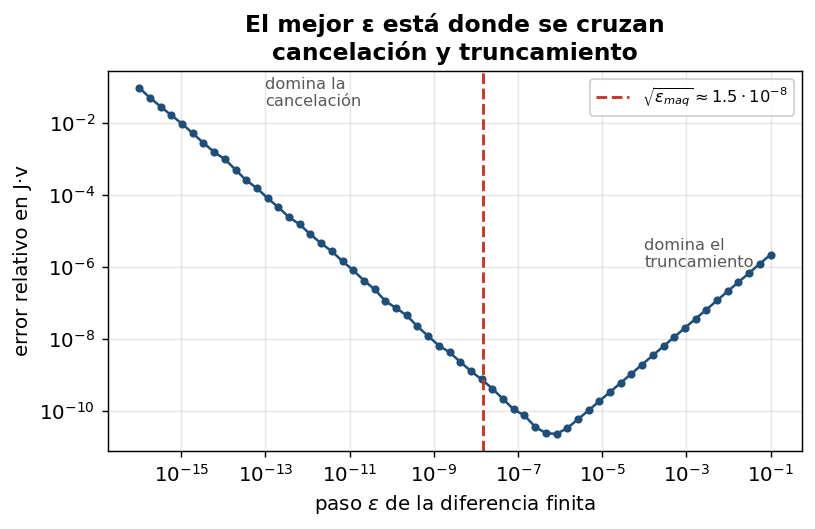

  → figuras/fig2a_epsilon.png


In [4]:
titulo("PARTE A · El producto J·v sin construir J")

u = 0.3 * np.sin(np.pi * MALLA)
Fu = F_bratu(u)
rng = np.random.default_rng(2025)
v = rng.standard_normal(N)

exacto = J_bratu_analitico(u) @ v
aprox = nk_lib.jv_diferencias_finitas(F_bratu, u, Fu, v)
err = np.linalg.norm(exacto - aprox) / np.linalg.norm(exacto)

print(f"""
  Dimensión del sistema        : N = {N}
  Entradas de J si la formamos : {N*N:,}
  Entradas que realmente usamos: 0  (nunca se almacena)

  Comprobación J·v por diferencias finitas contra el Jacobiano analítico:
  error relativo = {err:.3e}       (esperado ≈ √eps_maq ≈ {nk_lib.SQRT_EPS:.1e})

  Ese error NO es un defecto que se pueda corregir: es el mejor compromiso
  posible entre el error de truncamiento de la diferencia finita (crece con ε)
  y la cancelación por redondeo (crece al bajar ε). Y tiene una consecuencia
  directa: con J solo aproximada, la convergencia deja de ser exactamente
  cuadrática cerca de la raíz, y no se puede pedir un residuo final mucho
  menor que ‖F(x0)‖·√eps_maq.
""")

# --- barrido de epsilon, para verlo ---
epsilons = np.logspace(-16, -1, 60)
errores = []
for eps in epsilons:
    aprox_e = (F_bratu(u + eps * v) - Fu) / eps
    errores.append(np.linalg.norm(exacto - aprox_e) / np.linalg.norm(exacto))

fig, ax = plt.subplots(figsize=(6.4, 4.2))
ax.loglog(epsilons, errores, "o-", color="#1f4e79", ms=3.5, lw=1.4)
ax.axvline(nk_lib.SQRT_EPS, color="#c0392b", ls="--", lw=1.6,
           label=r"$\sqrt{\epsilon_{maq}} \approx 1.5\cdot10^{-8}$")
ax.set_xlabel(r"paso $\varepsilon$ de la diferencia finita")
ax.set_ylabel("error relativo en J·v")
ax.set_title("El mejor ε está donde se cruzan\ncancelación y truncamiento")
ax.legend(fontsize=9)
ax.text(1e-13, 3e-2, "domina la\ncancelación", fontsize=9, color="0.35")
ax.text(1e-4, 1e-6, "domina el\ntruncamiento", fontsize=9, color="0.35")
fig.savefig(f"{SALIDA}/fig2a_epsilon.png", bbox_inches="tight")
plt.show()
print(f"  → {SALIDA}/fig2a_epsilon.png")

In [5]:
titulo("PARTE A (bis) · El paso ε, en una tabla")

u = 0.3 * np.sin(np.pi * MALLA)
Fu = F_bratu(u)
v = np.random.default_rng(2025).standard_normal(N)
exacto = J_bratu_analitico(u) @ v

filas = []
for eps in (1e-16, 1e-14, 1e-12, 1e-10, 1e-8, 1e-6, 1e-4, 1e-2):
    aprox = (F_bratu(u + eps*v) - Fu) / eps
    err = np.linalg.norm(exacto - aprox) / np.linalg.norm(exacto)
    filas.append([f"{eps:.0e}", f"{err:.3e}",
                  "cancelación" if eps < 1e-7 else "truncamiento"])
tabla(filas, ["ε", "error relativo en J·v", "quién domina"])

epsilons = np.logspace(-16, -1, 200)
errores = np.array([np.linalg.norm(exacto - (F_bratu(u + e*v) - Fu)/e)
                    / np.linalg.norm(exacto) for e in epsilons])
i = int(np.argmin(errores))
err_receta = (np.linalg.norm(exacto - (F_bratu(u + nk_lib.SQRT_EPS*v) - Fu)/nk_lib.SQRT_EPS)
              / np.linalg.norm(exacto))
print(f"  ε que minimiza el error MEDIDO : {epsilons[i]:.3e}")
print(f"  error mínimo alcanzable        : {errores[i]:.3e}")
print(f"  √eps_maq (la receta)           : {nk_lib.SQRT_EPS:.3e}")
print(f"  error usando la receta         : {err_receta:.3e}")
print(f"""
  El mínimo medido no cae exactamente en √eps_maq porque en este problema el operador
  está dominado por su parte lineal: ‖F''‖ es chica frente a ‖F‖ y el óptimo se corre.
  Da igual: Newton inexacto tolera un residuo lineal de η‖F‖ con η ~ 1e-2, así que un
  Jacobiano con 7 cifras correctas le sobra.""")


  PARTE A (bis) · El paso ε, en una tabla
  -------+-----------------------+--------------
     ε   | error relativo en J·v | quién domina 
  -------+-----------------------+--------------
   1e-16 |       9.517e-02       | cancelación  
   1e-14 |       8.985e-04       | cancelación  
   1e-12 |       8.914e-06       | cancelación  
   1e-10 |       9.349e-08       | cancelación  
   1e-08 |       8.554e-10       | cancelación  
   1e-06 |       2.329e-11       | truncamiento 
   1e-04 |       2.213e-09       | truncamiento 
   1e-02 |       2.213e-07       | truncamiento 
  -------+-----------------------+--------------
  ε que minimiza el error MEDIDO : 7.488e-07
  error mínimo alcanzable        : 2.144e-11
  √eps_maq (la receta)           : 1.490e-08
  error usando la receta         : 6.933e-10

  El mínimo medido no cae exactamente en √eps_maq porque en este problema el operador
  está dominado por su parte lineal: ‖F''‖ es chica frente a ‖F‖ y el óptimo se corre.
  Da igual: New

## Partes B y C · ¿Cuán exactamente hay que resolver J s = −F?

In [6]:
CONFIGS = [(1e-1, "η = 1e-1 (fijo, flojo)", "#f39c12"),
           (1e-3, "η = 1e-3 (fijo, medio)", "#16a085"),
           (1e-12, "η = 1e-12 (fijo, casi exacto)", "#c0392b"),
           ("ew1", "Eisenstat-Walker 1", "#2980b9"),
           ("ew2", "Eisenstat-Walker 2", "#8e44ad")]


def corre_barrido(precond=None, etiqueta=""):
    u0 = np.zeros(N)
    resultados = {}
    for forzado, nombre, color in CONFIGS:
        t0 = time.perf_counter()
        h = nk_lib.newton_krylov(F_bratu, u0, globalizacion="linea",
                                 forzado=forzado, tol=1e-9, max_iter=60,
                                 precond=precond, gmres_maxiter=200)
        resultados[nombre] = (h, color, time.perf_counter() - t0)
    return resultados

In [7]:
titulo("PARTE B y C · ¿Cuán exactamente hay que resolver J s = −F?")

print("""
  El criterio de Newton inexacto es    ‖J s + F‖ ≤ η ‖F‖ .

  η grande  → poca precisión, GMRES termina rápido, pero el paso es malo y
          hacen falta más iteraciones de Newton.
  η chico   → paso casi exacto, pocas iteraciones de Newton, pero cada una
          cuesta muchísimos productos J·v.

  Y aquí está la trampa: lejos de la raíz el modelo lineal J s = −F ni
  siquiera describe bien a F, así que gastar trabajo en resolverlo con 12
  cifras es tirar el dinero. A eso se le llama OVERSOLVING.

  La columna que hay que mirar NO es "iteraciones de Newton" sino
  "productos J·v", porque cada producto J·v cuesta una evaluación de F, que
  es lo caro de verdad en un problema real.
""")

resultados = corre_barrido()
filas = []
for nombre, (h, _c, t) in resultados.items():
    filas.append([nombre,
                  "sí" if h.convergio else "NO",
                  h.n_newton,
                  f"{h.n_Jv:,}",
                  f"{h.n_F:,}",
                  f"{t*1000:.0f} ms",
                  f"{h.residuales[-1]:.1e}"])
tabla(filas, ["término de forzado", "conv.", "iters. Newton",
              "productos J·v", "evals. de F", "tiempo", "‖F‖ final"])

mejor = min(resultados.items(), key=lambda kv: kv[1][0].n_Jv)
peor = max(resultados.items(), key=lambda kv: kv[1][0].n_Jv)
print(f"""
  Más barato : {mejor[0]:32s} {mejor[1][0].n_Jv:>7,} productos J·v
  Más caro   : {peor[0]:32s} {peor[1][0].n_Jv:>7,} productos J·v
  Factor     : {peor[1][0].n_Jv / max(mejor[1][0].n_Jv,1):.1f}× más trabajo por resolver de más.

  Fíjense en que el más caro es también el que menos iteraciones de Newton
  usa. Contar iteraciones externas es engañoso: mide lo que se ve, no lo que
  se paga.
""")

sin_precond = resultados


  PARTE B y C · ¿Cuán exactamente hay que resolver J s = −F?

  El criterio de Newton inexacto es    ‖J s + F‖ ≤ η ‖F‖ .

  η grande  → poca precisión, GMRES termina rápido, pero el paso es malo y
          hacen falta más iteraciones de Newton.
  η chico   → paso casi exacto, pocas iteraciones de Newton, pero cada una
          cuesta muchísimos productos J·v.

  Y aquí está la trampa: lejos de la raíz el modelo lineal J s = −F ni
  siquiera describe bien a F, así que gastar trabajo en resolverlo con 12
  cifras es tirar el dinero. A eso se le llama OVERSOLVING.

  La columna que hay que mirar NO es "iteraciones de Newton" sino
  "productos J·v", porque cada producto J·v cuesta una evaluación de F, que
  es lo caro de verdad en un problema real.



  -------------------------------+-------+---------------+---------------+-------------+---------+-----------
         término de forzado      | conv. | iters. Newton | productos J·v | evals. de F |  tiempo | ‖F‖ final 
  -------------------------------+-------+---------------+---------------+-------------+---------+-----------
       η = 1e-1 (fijo, flojo)    |   sí  |       7       |     9,854     |    9,862    | 1844 ms |  2.2e-10  
       η = 1e-3 (fijo, medio)    |   sí  |       4       |     21,332    |    21,337   | 3871 ms |  9.5e-12  
   η = 1e-12 (fijo, casi exacto) |   sí  |       4       |     24,804    |    24,809   | 4593 ms |  1.1e-11  
         Eisenstat-Walker 1      |   sí  |       8       |     10,495    |    10,504   | 1925 ms |  5.0e-10  
         Eisenstat-Walker 2      |   sí  |       8       |     9,707     |    9,716    | 1784 ms |  5.1e-10  
  -------------------------------+-------+---------------+---------------+-------------+---------+-----------

  Más bar

## Parte D · Precondicionamiento


  PARTE D · Precondicionamiento: el mismo problema, mucho menos trabajo

  GMRES converge rápido cuando los autovalores del operador están agrupados.
  El Jacobiano de Bratu hereda del laplaciano un número de condición que
  crece como 1/h² = O(N²): con N = 250 eso son unas 25 000 unidades, y GMRES
  necesita muchísimas iteraciones para cada paso de Newton.

  El arreglo estándar: resolver M⁻¹ J s = −M⁻¹ F con M = laplaciano discreto,
  que es tridiagonal y se factoriza una sola vez en O(N).



  -------------------------------+------------------+------------------+----------
         término de forzado      | J·v sin precond. | J·v con precond. | ganancia 
  -------------------------------+------------------+------------------+----------
       η = 1e-1 (fijo, flojo)    |      9,854       |        19        |  518.6×  
       η = 1e-3 (fijo, medio)    |      21,332      |        24        |  888.8×  
   η = 1e-12 (fijo, casi exacto) |      24,804      |      24,603      |   1.0×   
         Eisenstat-Walker 1      |      10,495      |        22        |  477.0×  
         Eisenstat-Walker 2      |      9,707       |        22        |  441.2×  
  -------------------------------+------------------+------------------+----------

  Dos cosas que hay que señalar en voz alta al mostrar esta tabla:

  1) La ganancia es enorme porque el laplaciano es casi todo el Jacobiano:
 el término no lineal −h²λe^u es una perturbación diagonal pequeña. En un
 problema con convección dominante 

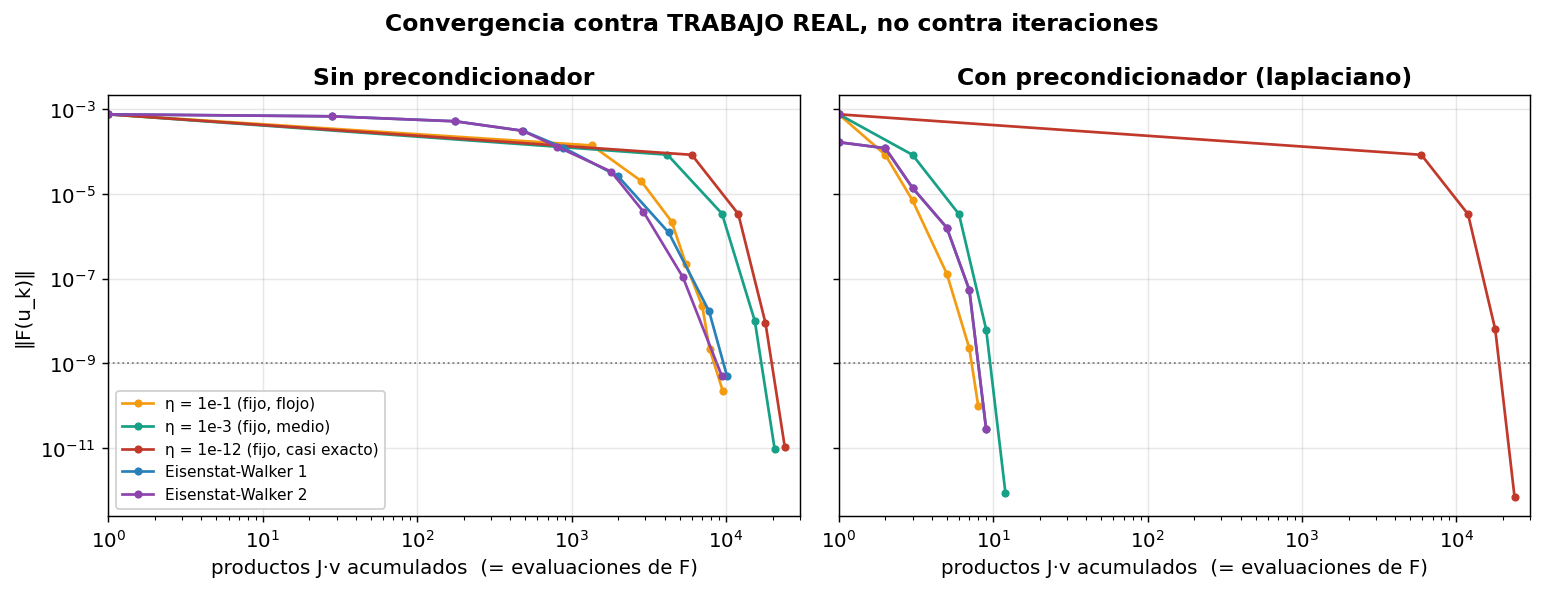


  → figuras/fig2b_residual_vs_trabajo.png


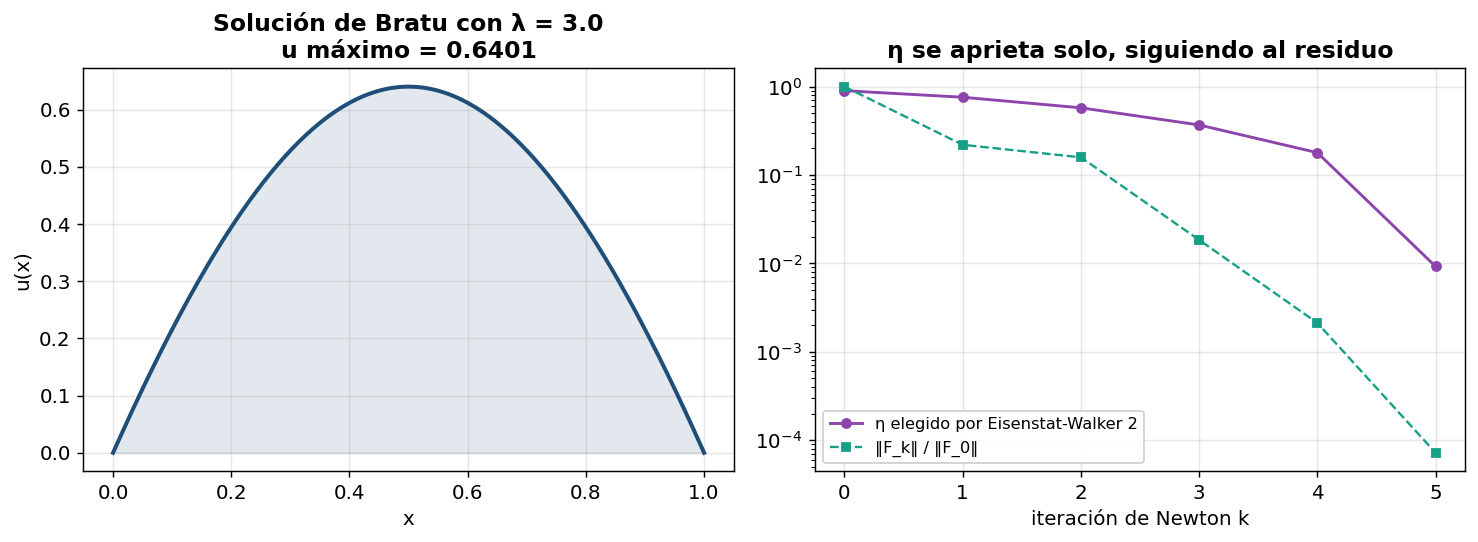

  → figuras/fig2c_solucion_eta.png


In [8]:
titulo("PARTE D · Precondicionamiento: el mismo problema, mucho menos trabajo")

print("""
  GMRES converge rápido cuando los autovalores del operador están agrupados.
  El Jacobiano de Bratu hereda del laplaciano un número de condición que
  crece como 1/h² = O(N²): con N = 250 eso son unas 25 000 unidades, y GMRES
  necesita muchísimas iteraciones para cada paso de Newton.

  El arreglo estándar: resolver M⁻¹ J s = −M⁻¹ F con M = laplaciano discreto,
  que es tridiagonal y se factoriza una sola vez en O(N).
""")

M = precondicionador_laplaciano()
con_precond = corre_barrido(precond=M)

filas = []
for nombre in [c[1] for c in CONFIGS]:
    h_sin = sin_precond[nombre][0]
    h_con = con_precond[nombre][0]
    factor = h_sin.n_Jv / max(h_con.n_Jv, 1)
    filas.append([nombre, f"{h_sin.n_Jv:,}", f"{h_con.n_Jv:,}", f"{factor:.1f}×"])
tabla(filas, ["término de forzado", "J·v sin precond.",
              "J·v con precond.", "ganancia"])

print("""
  Dos cosas que hay que señalar en voz alta al mostrar esta tabla:

  1) La ganancia es enorme porque el laplaciano es casi todo el Jacobiano:
 el término no lineal −h²λe^u es una perturbación diagonal pequeña. En un
 problema con convección dominante el precondicionador tendría que
 incluirla, y la ganancia sería menor. No hay precondicionador universal:
 hay que conocer el operador.

  2) La fila de η = 1e-12 NO mejora. Y es lógico: le estamos pidiendo a GMRES
 un residuo relativo de 1e-12, por debajo de lo que la aritmética de doble
 precisión puede entregar sobre este operador. GMRES no puede alcanzarlo,
 agota su presupuesto de iteraciones en cada paso de Newton y el
 precondicionador no lo salva. Pedir más precisión de la que existe no
 acelera nada: solo quema trabajo.
""")

# --- figura clave: residuo contra TRABAJO, no contra iteración ---
fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 4.6), sharey=True)
for ax, resultados, titulo_ax in [(a1, sin_precond, "Sin precondicionador"),
                                  (a2, con_precond, "Con precondicionador (laplaciano)")]:
    for nombre, (h, color, _t) in resultados.items():
        # Eje x logarítmico: con precondicionador el trabajo baja tres
        # órdenes de magnitud y en escala lineal las curvas buenas se
        # aplastarían contra el cero.
        trabajo = np.maximum(h.trabajo_acumulado, 1)
        ax.loglog(trabajo, h.residuales[:len(trabajo)], "o-", color=color,
                  ms=3.5, lw=1.5, label=nombre)
    ax.set_xlabel("productos J·v acumulados  (= evaluaciones de F)")
    ax.set_title(titulo_ax)
    ax.set_xlim(1, 3e4)
    ax.axhline(1e-9, color="0.5", ls=":", lw=1)
a1.set_ylabel("‖F(u_k)‖")
a1.legend(fontsize=8.5)
fig.suptitle("Convergencia contra TRABAJO REAL, no contra iteraciones",
             fontsize=13, fontweight="bold")
fig.savefig(f"{SALIDA}/fig2b_residual_vs_trabajo.png", bbox_inches="tight")
plt.show()
print(f"\n  → {SALIDA}/fig2b_residual_vs_trabajo.png")

# --- figura: la solución y la evolución de eta ---
h_ew = con_precond["Eisenstat-Walker 2"][0]
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11.5, 4.3))

ub = np.zeros(N + 2)
ub[1:-1] = h_ew.x
a1.plot(np.linspace(0, 1, N + 2), ub, color="#1f4e79", lw=2.2)
a1.fill_between(np.linspace(0, 1, N + 2), 0, ub, color="#1f4e79", alpha=0.13)
a1.set_xlabel("x")
a1.set_ylabel("u(x)")
a1.set_title(f"Solución de Bratu con λ = {LAMBDA}\n"
             f"u máximo = {ub.max():.4f}")

a2.semilogy(h_ew.etas, "o-", color="#8e44ad", ms=5, lw=1.6,
            label="η elegido por Eisenstat-Walker 2")
a2.semilogy(np.array(h_ew.residuales[:-1]) / h_ew.residuales[0], "s--",
            color="#16a085", ms=4, lw=1.3, label="‖F_k‖ / ‖F_0‖")
a2.set_xlabel("iteración de Newton k")
a2.set_title("η se aprieta solo, siguiendo al residuo")
a2.legend(fontsize=9)
fig.savefig(f"{SALIDA}/fig2c_solucion_eta.png", bbox_inches="tight")
plt.show()
print(f"  → {SALIDA}/fig2c_solucion_eta.png")

## Parte E · Contraste con scipy.optimize.newton_krylov

In [9]:
titulo("PARTE E · Contraste con scipy.optimize.newton_krylov")

h_nuestro = con_precond["Eisenstat-Walker 2"][0]

t0 = time.perf_counter()
u_scipy = scipy_newton_krylov(F_bratu, np.zeros(N), method="lgmres",
                              f_tol=1e-9, verbose=False)
t_scipy = time.perf_counter() - t0

dif = np.linalg.norm(h_nuestro.x - u_scipy) / np.linalg.norm(u_scipy)
print(f"""
  scipy.optimize.newton_krylov es exactamente esta misma familia de métodos:
  Newton inexacto + Krylov matriz-libre + búsqueda de línea. Es la referencia
  contra la que hay que validar nuestra implementación.

  ‖F‖ final, nuestra implementación : {h_nuestro.residuales[-1]:.3e}
  ‖F‖ final, SciPy                  : {np.linalg.norm(F_bratu(u_scipy)):.3e}
  diferencia relativa entre soluciones: {dif:.3e}

  Coinciden. La diferencia está en el orden de la precisión alcanzable con un
  Jacobiano por diferencias finitas, que es lo que se espera.
""")
tabla([["nuestra (EW2 + precond.)", f"{h_nuestro.n_newton}",
        f"{h_nuestro.n_F:,}", f"{con_precond['Eisenstat-Walker 2'][2]*1000:.0f} ms"],
       ["scipy.optimize.newton_krylov", "—", "—", f"{t_scipy*1000:.0f} ms"]],
      ["implementación", "iters. Newton", "evals. de F", "tiempo"])


  PARTE E · Contraste con scipy.optimize.newton_krylov

  scipy.optimize.newton_krylov es exactamente esta misma familia de métodos:
  Newton inexacto + Krylov matriz-libre + búsqueda de línea. Es la referencia
  contra la que hay que validar nuestra implementación.

  ‖F‖ final, nuestra implementación : 2.778e-11
  ‖F‖ final, SciPy                  : 1.406e-09
  diferencia relativa entre soluciones: 8.585e-08

  Coinciden. La diferencia está en el orden de la precisión alcanzable con un
  Jacobiano por diferencias finitas, que es lo que se espera.

  ------------------------------+---------------+-------------+--------
          implementación        | iters. Newton | evals. de F | tiempo 
  ------------------------------+---------------+-------------+--------
     nuestra (EW2 + precond.)   |       6       |      29     |  1 ms  
   scipy.optimize.newton_krylov |       —       |      —      | 22 ms  
  ------------------------------+---------------+-------------+--------


In [10]:
titulo("FIN DEL EJERCICIO 2")


  FIN DEL EJERCICIO 2
